In [269]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [270]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [271]:
df_train=pd.read_csv("/content/drive/MyDrive/house-prices-advanced-regression-techniques/train.csv")
df_test=pd.read_csv("/content/drive/MyDrive/house-prices-advanced-regression-techniques/test.csv")

In [272]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [273]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [274]:
df_train.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [275]:
df_test.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,4
LotFrontage,227
LotArea,0
...,...
MiscVal,0
MoSold,0
YrSold,0
SaleType,1


<Axes: >

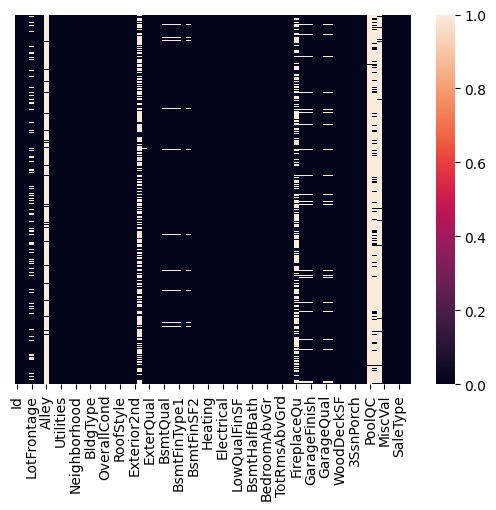

In [276]:
sns.heatmap(df_train.isnull(),yticklabels=False,cbar=True)

<Axes: >

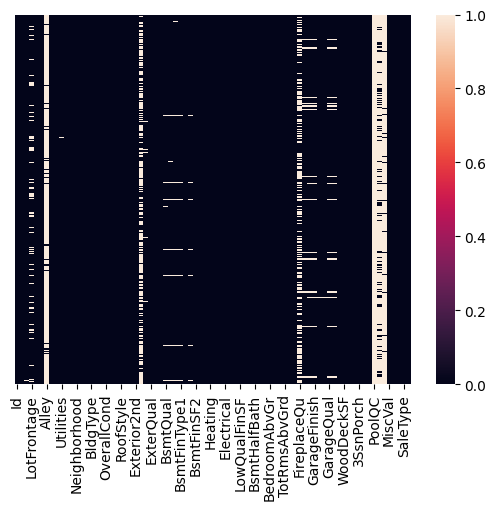

In [277]:
sns.heatmap(df_test.isnull(),yticklabels=False,cbar=True)

In [278]:
df_train['LotFrontage']=df_train['LotFrontage'].fillna(df_train['LotFrontage'].mean())

In [279]:
df_test['LotFrontage']=df_test['LotFrontage'].fillna(df_test['LotFrontage'].mean())

In [280]:
df_train.drop(['Alley'],axis=1,inplace=True)

In [281]:
df_train['BsmtCond']=df_train['BsmtCond'].fillna(df_train['BsmtCond'].mode()[0])
df_train['BsmtQual']=df_train['BsmtQual'].fillna(df_train['BsmtQual'].mode()[0])
df_train['FireplaceQu']=df_train['FireplaceQu'].fillna(df_train['FireplaceQu'].mode()[0])
df_train['GarageType']=df_train['GarageType'].fillna(df_train['GarageType'].mode()[0])
df_train['GarageFinish']=df_train['GarageFinish'].fillna(df_train['GarageFinish'].mode()[0])
df_train['GarageQual']=df_train['GarageQual'].fillna(df_train['GarageQual'].mode()[0])
df_train['GarageCond']=df_train['GarageCond'].fillna(df_train['GarageCond'].mode()[0])
df_train['MasVnrType']=df_train['MasVnrType'].fillna(df_train['MasVnrType'].mode()[0])
df_train['MasVnrArea']=df_train['MasVnrArea'].fillna(df_train['MasVnrArea'].mode()[0])

In [282]:
df_test['BsmtCond'] = df_test['BsmtCond'].fillna(df_test['BsmtCond'].mode()[0])
df_test['BsmtQual'] = df_test['BsmtQual'].fillna(df_test['BsmtQual'].mode()[0])
df_test['BsmtExposure'] = df_test['BsmtExposure'].fillna(df_test['BsmtExposure'].mode()[0])
df_test['BsmtFinType2'] = df_test['BsmtFinType2'].fillna(df_test['BsmtFinType2'].mode()[0])
df_test['FireplaceQu'] = df_test['FireplaceQu'].fillna(df_test['FireplaceQu'].mode()[0])
df_test['GarageType'] = df_test['GarageType'].fillna(df_test['GarageType'].mode()[0])
df_test['GarageFinish'] = df_test['GarageFinish'].fillna(df_test['GarageFinish'].mode()[0])
df_test['GarageQual'] = df_test['GarageQual'].fillna(df_test['GarageQual'].mode()[0])
df_test['GarageCond'] = df_test['GarageCond'].fillna(df_test['GarageCond'].mode()[0])
df_test['MasVnrType'] = df_test['MasVnrType'].fillna(df_test['MasVnrType'].mode()[0])
df_test['MasVnrArea'] = df_test['MasVnrArea'].fillna(df_test['MasVnrArea'].mode()[0])

In [283]:
df_train.drop(['GarageYrBlt'],axis=1,inplace=True)


In [284]:
df_train.drop(['PoolQC','Fence','MiscFeature'],axis=1,inplace=True)

In [285]:
df_train.shape

(1460, 76)

In [286]:
df_train.drop(['Id'],axis=1,inplace=True)

In [287]:
df_test.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,4
LotFrontage,0
LotArea,0
...,...
MiscVal,0
MoSold,0
YrSold,0
SaleType,1


In [288]:
df_test.isnull().sum()[df_test.isnull().sum() > 0]

,0
MSZoning,4
Alley,1352
Utilities,2
Exterior1st,1
Exterior2nd,1
BsmtFinType1,42
BsmtFinSF1,1
BsmtFinSF2,1
BsmtUnfSF,1
TotalBsmtSF,1


<Axes: >

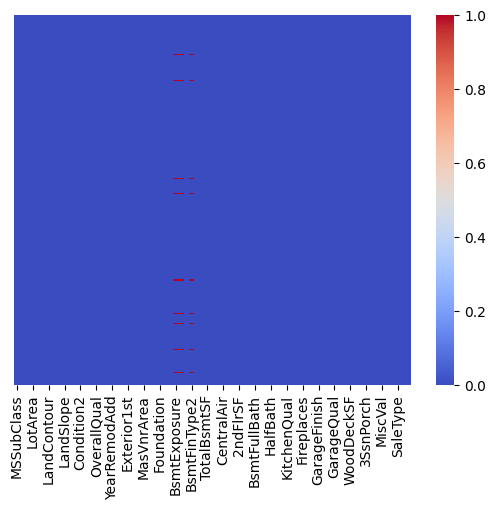

In [289]:
sns.heatmap(df_train.isnull(),yticklabels=False,cbar=True,cmap='coolwarm')

In [290]:
df_train['BsmtExposure']=df_train['BsmtExposure'].fillna(df_train['BsmtExposure'].mode()[0])

<Axes: >

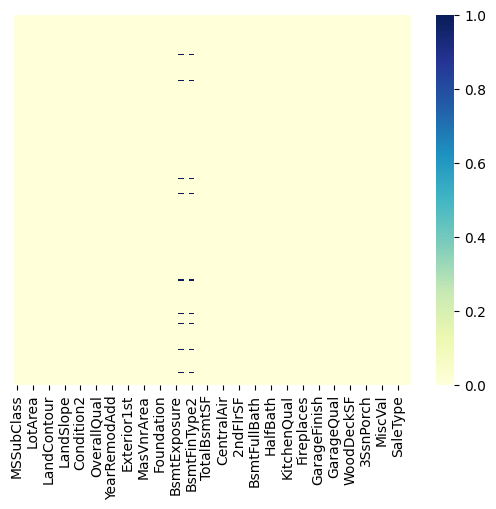

In [291]:
sns.heatmap(df_train.isnull(),yticklabels=False,cbar=True,cmap='YlGnBu')

In [292]:
df_train['BsmtFinType2']=df_train['BsmtFinType2'].fillna(df_train['BsmtFinType2'].mode()[0])

In [293]:
df_train.dropna(inplace=True)

In [294]:
df_train.shape

(1422, 75)

In [295]:
df_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [296]:
columns=list(df_train.columns)

In [297]:
len(columns)

75

In [298]:
df_test.drop(['Alley'], axis=1, inplace=True)
df_test.drop(['GarageYrBlt'], axis=1, inplace=True)
df_test.drop(['PoolQC', 'Fence', 'MiscFeature'], axis=1, inplace=True)

test_ids = df_test['Id']
df_test.drop(['Id'], axis=1, inplace=True)

In [299]:
for col in df_train.select_dtypes(include=['int64','float64']):
    df_train[col] = df_train[col].fillna(df_train[col].mean())

In [300]:
for col in df_train.select_dtypes(include='object'):
    df_train[col] = df_train[col].fillna(df_train[col].mode()[0])

In [301]:
df_train.isnull().sum().sum()


np.int64(0)

In [302]:
df_test.isnull().sum().sum()

np.int64(64)

In [303]:
df_test.isnull().sum()[df_test.isnull().sum() > 0]

,0
MSZoning,4
Utilities,2
Exterior1st,1
Exterior2nd,1
BsmtFinType1,42
BsmtFinSF1,1
BsmtFinSF2,1
BsmtUnfSF,1
TotalBsmtSF,1
BsmtFullBath,2


In [304]:
for col in df_test.select_dtypes(include=['int64', 'float64']).columns:
    df_test[col] = df_test[col].fillna(df_test[col].mean())

In [305]:
for col in df_test.select_dtypes(include='object').columns:
    df_test[col] = df_test[col].fillna(df_test[col].mode().iloc[0])

In [306]:
print(df_test.isnull().sum().sum())

0


In [307]:
X = df_train[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df_train['SalePrice']

X_test_final = df_test[['GrLivArea', 'BedroomAbvGr', 'FullBath']]

In [308]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [309]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [310]:
lr.fit(X_train, y_train)
y_pred = lr.predict(X_val)

In [311]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 37184.0739354465
Mean Squared Error : 3241467728.165711
Root Mean Squared Error : 56933.889101006534
R2 Score : 0.45132514659185485


In [312]:
print(df_test.isnull().sum().sum())

0


In [313]:
X = df_train[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df_train['SalePrice']

X_test_final = df_test[['GrLivArea', 'BedroomAbvGr', 'FullBath']]

In [314]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [315]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [316]:
lr.fit(X_train, y_train)
y_pred = lr.predict(X_val)

In [317]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 37184.0739354465
Mean Squared Error : 3241467728.165711
Root Mean Squared Error : 56933.889101006534
R2 Score : 0.45132514659185485


In [318]:
unknown_house = pd.DataFrame({
    'GrLivArea': [2200],
    'BedroomAbvGr': [3],
    'FullBath': [2]
})

predicted_price = lr.predict(unknown_house)

print("Predicted House Price = ${:,.2f}".format(predicted_price[0]))

Predicted House Price = $272,694.52


In [319]:
predicted_price = lr.predict(unknown_house)

print("Predicted House Price = ${:,.2f}".format(predicted_price[0]))

Predicted House Price = $272,694.52


In [320]:
predicted_price = lr.predict(unknown_house)

print("Predicted House Price = ${:,.2f}".format(predicted_price[0]))

Predicted House Price = $272,694.52
